In [13]:
!pip install control
!pip install matplotlib
!pip install numpy
!pip install plotly

In [14]:
import numpy as np
import control as cnt
import matplotlib.pyplot as plt

In [15]:
def planta(K, tau, theta, n_pade=10):
    """FOPDT com atraso aproximado por Pade."""
    H = cnt.tf([K], [tau, 1])
    num_p, den_p = cnt.pade(theta, n_pade)
    return cnt.series(H, cnt.tf(num_p, den_p))

def pid(Kp, Ti, Td):
    """PID paralelo ideal: Kp + Kp/(Ti s) + Kp Td s"""
    P = cnt.tf([Kp], [1])
    I = cnt.tf([Kp], [Ti, 0])
    D = cnt.tf([Kp*Td, 0], [1])
    return cnt.parallel(cnt.parallel(P, I), D)

def malha_fechada(K, tau, theta, Kp, Ti, Td):
    return cnt.feedback(cnt.series(planta(K, tau, theta), pid(Kp, Ti, Td)), 1)

def resposta(K, tau, theta, Kp, Ti, Td, amp=1.0, tmax=100, n=4000):
    t = np.linspace(0, tmax, n)
    t, y = cnt.step_response(malha_fechada(K, tau, theta, Kp, Ti, Td), t)
    return t, y*amp

def metricas(t, y, ref):
    os = (y.max() - ref)/ref*100
    fora = np.where(np.abs(y - ref) > 0.02*ref)[0]
    ts = t[fora[-1]] if len(fora) else 0.0
    return os, ts

# --- fórmulas de sintonia ---
zn    = lambda K, tau, th: (1.2*tau/(K*th), 2*th, 0.5*th)
chr0  = lambda K, tau, th: (0.6*tau/(K*th), tau, 0.5*th)
chr20 = lambda K, tau, th: (0.95*tau/(K*th), 1.357*tau, 0.473*th)
def imc(K, tau, th, lam):
    return ((2*tau + th)/(2*K*(lam + th)), tau + th/2, tau*th/(2*tau + th))


---
## Questão 1 — Estufa agrícola

### a) Identificação pelo método de Smith



In [16]:
t1, t2 = 15, 42
tau1 = 1.5*(t2 - t1)
th1  = t2 - tau1
K1   = 12/0.20
print(f"K = {K1:.2f} | tau = {tau1:.2f} s | theta = {th1:.2f} s | theta/tau = {th1/tau1:.3f}")

K = 60.00 | tau = 40.50 s | theta = 1.50 s | theta/tau = 0.037


### b) Sintonias

In [17]:
lam1 = 1.5*th1   # escolha de lambda para o IMC (mesma da Q5a)
sint1 = {
    "Ziegler-Nichols": zn(K1, tau1, th1),
    "CHR 0% sobrevalor": chr0(K1, tau1, th1),
    f"IMC (lambda={lam1:.2f}s)": imc(K1, tau1, th1, lam1),
}
for nome, (Kp, Ti, Td) in sint1.items():
    print(f"{nome:<22} Kp = {Kp:7.4f} | Ti = {Ti:7.3f} s | Td = {Td:6.4f} s")

Ziegler-Nichols        Kp =  0.5400 | Ti =   3.000 s | Td = 0.7500 s
CHR 0% sobrevalor      Kp =  0.2700 | Ti =  40.500 s | Td = 0.7500 s
IMC (lambda=2.25s)     Kp =  0.1833 | Ti =  41.250 s | Td = 0.7364 s


### c) Resposta ao degrau unitário

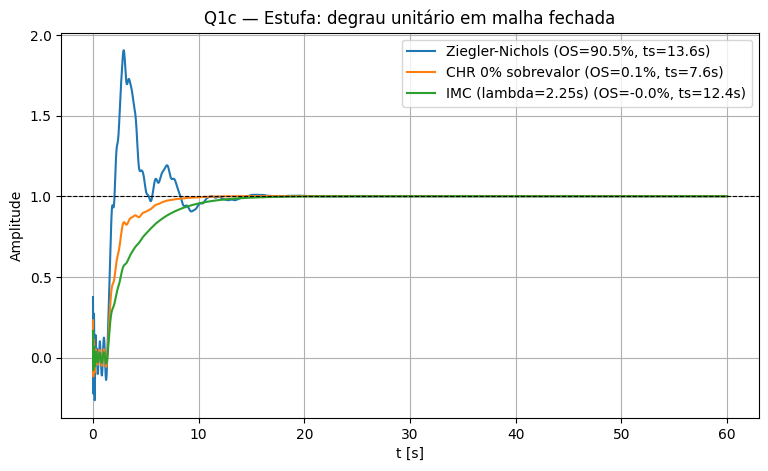

In [18]:
plt.figure(figsize=(9, 5))
for nome, (Kp, Ti, Td) in sint1.items():
    t, y = resposta(K1, tau1, th1, Kp, Ti, Td, amp=1.0, tmax=60)
    os, ts = metricas(t, y, 1.0)
    plt.plot(t, y, label=f"{nome} (OS={os:.1f}%, ts={ts:.1f}s)")
plt.axhline(1.0, color="k", ls="--", lw=0.8)
plt.xlabel("t [s]"); plt.ylabel("Amplitude")
plt.title("Q1c — Estufa: degrau unitário em malha fechada")
plt.legend(); plt.grid(True); plt.show()

---
## Questão 3 — Ziegler-Nichols malha aberta

In [19]:
sistemas3 = {
    "a) Irrigação  G=2,5 e^-4s/(20s+1)": (2.5, 20, 4.0),
    "b) Esteira    G=1,8 e^-0,8s/(3s+1)": (1.8, 3.0, 0.8),
}
atraso_wifi = 0.3
for nome, (K, tau, th) in sistemas3.items():
    Kp, Ti, Td = zn(K, tau, th)
    print(f"{nome}")
    print(f"   Kp = {Kp:.3f} | Ti = {Ti:.2f} s | Td = {Td:.2f} s")
    print(f"   theta = {th:.2f} s | theta/tau = {th/tau:.3f} | Ti/theta = {Ti/th:.1f}")
    print(f"   +300 ms representa {100*atraso_wifi/th:.1f}% do tempo morto, "
          f"{100*atraso_wifi/Ti:.1f}% de Ti e {100*atraso_wifi/tau:.1f}% de tau")
    th2 = th + atraso_wifi
    print(f"   theta/tau passaria de {th/tau:.3f} para {th2/tau:.3f}\n")

a) Irrigação  G=2,5 e^-4s/(20s+1)
   Kp = 2.400 | Ti = 8.00 s | Td = 2.00 s
   theta = 4.00 s | theta/tau = 0.200 | Ti/theta = 2.0
   +300 ms representa 7.5% do tempo morto, 3.8% de Ti e 1.5% de tau
   theta/tau passaria de 0.200 para 0.215

b) Esteira    G=1,8 e^-0,8s/(3s+1)
   Kp = 2.500 | Ti = 1.60 s | Td = 0.40 s
   theta = 0.80 s | theta/tau = 0.267 | Ti/theta = 2.0
   +300 ms representa 37.5% do tempo morto, 18.8% de Ti e 10.0% de tau
   theta/tau passaria de 0.267 para 0.367



---
## Questão 4 — Armário de rede (data center IoT)


In [20]:
K4, tau4, th4 = 1.5, 6.0, 1.0
sint4 = {
    "CHR 0% sobrevalor":  chr0(K4, tau4, th4),
    "CHR 20% sobrevalor": chr20(K4, tau4, th4),
}
for nome, (Kp, Ti, Td) in sint4.items():
    print(f"{nome:<20} Kp = {Kp:.3f} | Ti = {Ti:.3f} s | Td = {Td:.3f} s")

CHR 0% sobrevalor    Kp = 2.400 | Ti = 6.000 s | Td = 0.500 s
CHR 20% sobrevalor   Kp = 3.800 | Ti = 8.142 s | Td = 0.473 s


### c) Resposta a um degrau de valor 15

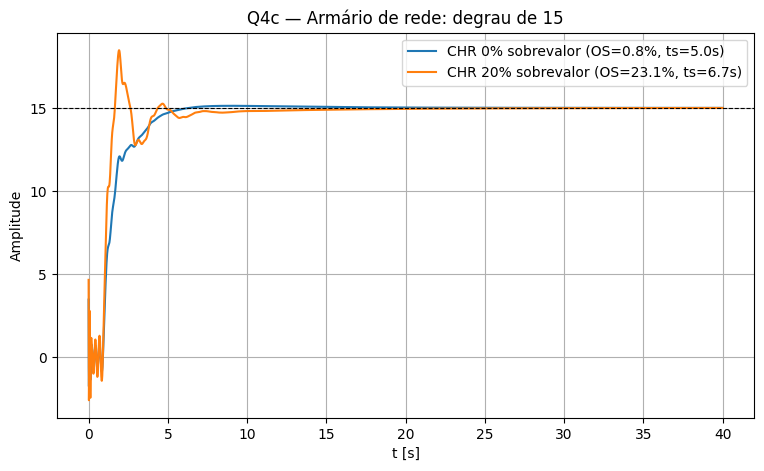

In [21]:
plt.figure(figsize=(9, 5))
for nome, (Kp, Ti, Td) in sint4.items():
    t, y = resposta(K4, tau4, th4, Kp, Ti, Td, amp=15, tmax=40)
    os, ts = metricas(t, y, 15)
    plt.plot(t, y, label=f"{nome} (OS={os:.1f}%, ts={ts:.1f}s)")
plt.axhline(15, color="k", ls="--", lw=0.8)
plt.xlabel("t [s]"); plt.ylabel("Amplitude")
plt.title("Q4c — Armário de rede: degrau de 15")
plt.legend(); plt.grid(True); plt.show()

---
## Questão 5 — Estufa por IMC


In [22]:
sint5 = {
    "IMC lambda = 1,5*theta = 2,25 s": imc(K1, tau1, th1, 1.5*th1),
    "IMC lambda = 4*theta = 6,00 s":   imc(K1, tau1, th1, 4.0*th1),
}
for nome, (Kp, Ti, Td) in sint5.items():
    print(f"{nome:<32} Kp = {Kp:.4f} | Ti = {Ti:.3f} s | Td = {Td:.4f} s")
print(f"\nRazão entre os Kp: {sint5['IMC lambda = 1,5*theta = 2,25 s'][0]/sint5['IMC lambda = 4*theta = 6,00 s'][0]:.2f}x")

IMC lambda = 1,5*theta = 2,25 s  Kp = 0.1833 | Ti = 41.250 s | Td = 0.7364 s
IMC lambda = 4*theta = 6,00 s    Kp = 0.0917 | Ti = 41.250 s | Td = 0.7364 s

Razão entre os Kp: 2.00x


### c) Resposta a um degrau de valor 20

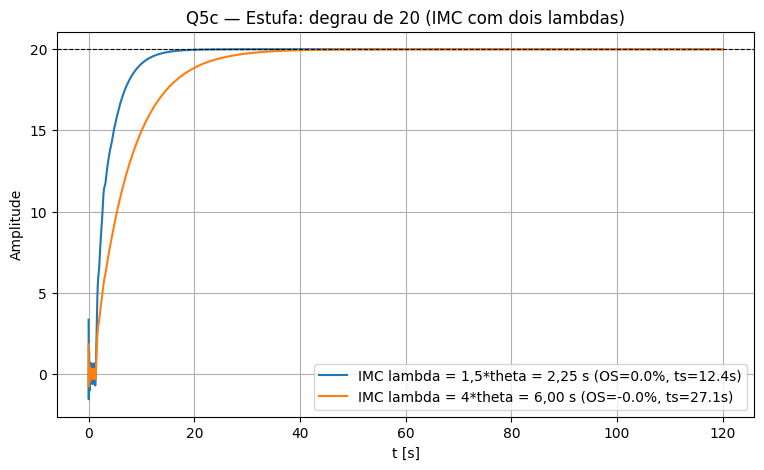

In [23]:
plt.figure(figsize=(9, 5))
for nome, (Kp, Ti, Td) in sint5.items():
    t, y = resposta(K1, tau1, th1, Kp, Ti, Td, amp=20, tmax=120)
    os, ts = metricas(t, y, 20)
    plt.plot(t, y, label=f"{nome} (OS={os:.1f}%, ts={ts:.1f}s)")
plt.axhline(20, color="k", ls="--", lw=0.8)
plt.xlabel("t [s]"); plt.ylabel("Amplitude")
plt.title("Q5c — Estufa: degrau de 20 (IMC com dois lambdas)")
plt.legend(); plt.grid(True); plt.show()